In [1]:
%%capture
!pip install datasetsforecast hierarchicalforecast mlforecast neuralforecast 

In [8]:
%%capture
pip install xgboost


In [9]:


import numpy as np
import pandas as pd

from datasetsforecast.hierarchical import HierarchicalData

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import GMM

from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals
import xgboost as xgb

#obtain hierarchical reconciliation methods and evaluation
from hierarchicalforecast.methods import BottomUp, ERM, MinTrace
from hierarchicalforecast.utils import HierarchicalPlot
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.evaluation import evaluate

In [4]:
import numpy as np
import pandas as pd

Y_df = pd.read_csv('https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/tourism.csv')

Y_df = Y_df.rename({'Trips': 'y', 'Quarter': 'ds'}, axis=1)

Y_df.insert(0, 'Country', 'Australia')

Y_df = Y_df[['Country', 'Region', 'State', 'Purpose', 'ds', 'y']]


Y_df['ds'] = Y_df['ds'].str.replace(r'(\d+) (Q\d)', r'\1-\2', regex=True)

Y_df['ds'] = pd.PeriodIndex(Y_df["ds"], freq='Q').to_timestamp()

spec = [
    ['Country'],
    ['Country', 'State'], 
    ['Country', 'Purpose'], 
    ['Country', 'State', 'Region'], 
    ['Country', 'State', 'Purpose'], 
    ['Country', 'State', 'Region', 'Purpose']
]
from hierarchicalforecast.utils import aggregate


Y_df, S_df, tags = aggregate(Y_df, spec)

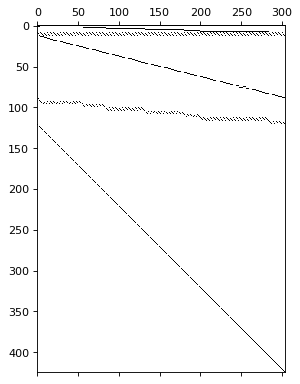

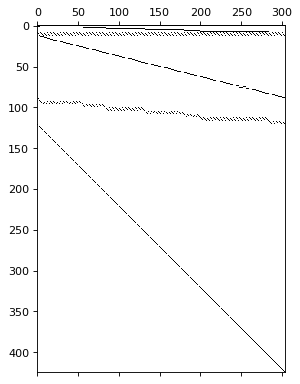

In [10]:
hplot = HierarchicalPlot(S=S_df, tags=tags)
hplot.plot_summing_matrix()

In [11]:
horizon = 8
Y_test_df = Y_df.groupby('unique_id', as_index=False).tail(horizon)
Y_train_df = Y_df.drop(Y_test_df.index)

In [15]:
Y_test_df.head() , Y_train_df.head()

(    unique_id         ds             y
 72  Australia 2016-01-01  26660.637689
 73  Australia 2016-04-01  24285.027757
 74  Australia 2016-07-01  24191.320131
 75  Australia 2016-10-01  26347.600973
 76  Australia 2017-01-01  27496.389021,
    unique_id         ds             y
 0  Australia 1998-01-01  23182.197269
 1  Australia 1998-04-01  20323.380067
 2  Australia 1998-07-01  19826.640511
 3  Australia 1998-10-01  20830.129891
 4  Australia 1999-01-01  22087.353380)

In [18]:
level = np.arange(0, 100, 2)
qs = [[50-lv/2, 50+lv/2] for lv in level]
quantiles = np.sort(np.concatenate(qs)[1:]/100)

#fit/predict NBEATS from NeuralForecast
nbeats = NBEATS(h=horizon,
              input_size=2*horizon,
              loss=GMM(n_components=10, quantiles=quantiles),
              scaler_type='robust',
              max_steps=150)
nf = NeuralForecast(models=[nbeats], freq='QS')
nf.fit(df=Y_train_df)
Y_hat_nf = nf.predict()
insample_nf = nf.predict_insample(step_size=horizon)

#fit/predict XGBRegressor from MLForecast
mf = MLForecast(models=[xgb.XGBRegressor()], 
                freq='QS',
                lags=[1,2,12,24],
                date_features=['quarter'],
                )
mf.fit(Y_train_df, fitted=True, prediction_intervals=PredictionIntervals(n_windows=6, h=horizon)) 
Y_hat_mf = mf.predict(horizon, level=level)
insample_mf = mf.forecast_fitted_values()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | GMM           | 99     | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.7 M  | train
-------------------------------------------------------
2.7 M     Trainable params
507       Non-trainable params
2.7 M     Total params
10.656    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Epoch 10: 100%|██████████| 10/10 [00:00<00:00, 23.26it/s, v_num=1282, train_loss_step=4.380, train_loss_epoch=4.270]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=150` reached.


Epoch 10: 100%|██████████| 10/10 [00:00<00:00, 23.15it/s, v_num=1282, train_loss_step=4.380, train_loss_epoch=4.270]


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 37.42it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 41.46it/s]


/Users/smsag/Desktop/Thesis/codes/hts/lib/python3.9/site-packages/mlforecast/core.py:434: UserWarning: The following series were dropped completely due to the transformations and features: ['Australia', 'Australia/ACT', 'Australia/ACT/Business', 'Australia/ACT/Canberra', 'Australia/AC...erra/Business', 'Australia/AC...berra/Holiday', ...].
These series won't show up if you use `MLForecast.forecast_fitted_values()`.
You can set `dropna=False` or use transformations that require less samples to mitigate this
  warnings.warn(
/Users/smsag/Desktop/Thesis/codes/hts/lib/python3.9/site-packages/utilsforecast/processing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[names] = values
/Users/smsag/Desktop/Thesis/codes/hts/lib/python3.9/site-packages/utilsfor

In [19]:
reconcilers = [
    ERM(method='closed'),
    BottomUp(),
    MinTrace('mint_shrink'),
]
hrec = HierarchicalReconciliation(reconcilers=reconcilers)

Y_rec_nf = hrec.reconcile(Y_hat_df=Y_hat_nf, Y_df=insample_nf, S_df=S_df, tags=tags, level=level)
Y_rec_mf = hrec.reconcile(Y_hat_df=Y_hat_mf, Y_df=insample_mf, S_df=S_df, tags=tags, level=level)

Epoch 7:  79%|███████▊  | 11/14 [02:16<00:37,  0.08it/s, v_num=854, train_loss_step=4.030, train_loss_epoch=4.280]


In [25]:
from utilsforecast.losses import scaled_crps
from utilsforecast.losses import rmse, mase
from functools import partial



In [27]:
rec_model_names_nf = ['NBEATS/BottomUp', 'NBEATS/MinTrace_method-mint_shrink', 'NBEATS/ERM_method-closed_lambda_reg-0.01']

evaluation_nf = evaluate(df = Y_rec_nf.merge(Y_test_df, on=['unique_id', 'ds']),
                         train_df=Y_train_df,
                      tags = tags,
                      metrics = [rmse,
                                 partial(mase, seasonality=4)],
                      models= rec_model_names_nf,
                      level = list(range(0, 100, 2)),
                      )

rec_model_names_mf = ['XGBRegressor/BottomUp', 'XGBRegressor/MinTrace_method-mint_shrink', 'XGBRegressor/ERM_method-closed_lambda_reg-0.01']

evaluation_mf = evaluate(df = Y_rec_mf.merge(Y_test_df, on=['unique_id', 'ds']),
                         train_df=Y_train_df,
                      tags = tags,
                      metrics = [rmse,
                                 partial(mase, seasonality=4)],
                      models= rec_model_names_mf,
                      level = list(range(0, 100, 2)),
                      )

In [22]:
name = 'NBEATS/BottomUp'
quantile_columns = [col for col in Y_rec_mf.columns if (name+'-lo') in col or (name+'-hi') in col]


In [30]:
evaluation_nf.query('metric == "mase"')

,level,metric,NBEATS/BottomUp,NBEATS/MinTrace_method-mint_shrink,NBEATS/ERM_method-closed_lambda_reg-0.01
1,Country,mase,2.525521,2.478106,12.806587
3,Country/State,mase,1.503773,1.473997,21.736030
5,Country/Purpose,mase,1.776916,1.801648,14.420022
7,Country/State/Region,mase,1.073437,1.064058,22.703971
9,Country/State/Purpose,mase,1.134892,1.133156,23.023882
11,Country/State/Region/Purpose,mase,0.957981,0.952351,22.299916
13,Overall,mase,1.013618,1.007343,22.319566


In [31]:
evaluation_mf.query('metric == "mase"')

,level,metric,XGBRegressor/BottomUp,XGBRegressor/MinTrace_method-mint_shrink,XGBRegressor/ERM_method-closed_lambda_reg-0.01
1,Country,mase,4.422504,2.342417,2.291505
3,Country/State,mase,2.541352,1.606502,1.934932
5,Country/Purpose,mase,3.148289,1.803619,1.762328
7,Country/State/Region,mase,1.478929,1.198493,1.731187
9,Country/State/Purpose,mase,1.755676,1.319728,1.641926
11,Country/State/Region/Purpose,mase,1.157676,1.103656,1.531565
13,Overall,mase,1.312613,1.155852,1.587124
